# Degradar resolución espectral — Plantilla reutilizable

Convierte un espectro de alta resolución `R_in` a una resolución más baja `R_out` (e.g. 85 000 → 1300 LAMOST) con:

1. **Convolución Gaussiana** que cuadra el FWHM al de la resolución objetivo.
2. **Re-muestreo conservando flujo** (`specutils.FluxConservingResampler`) a una grilla de longitud de onda configurable (lineal o log-uniforme).
3. **Inyección de ruido opcional** para llegar a un RMS objetivo (e.g. el RMS típico de tu instrumento de baja resolución).

Adaptado del pipeline en `notebooks/4_clasificar_standards.ipynb`, generalizado: lector y grilla de salida son parámetros.

**Editar solo la celda `CONFIG`.**

## 0. EJEMPLO RÁPIDO (estándar Melchior/HERMES → LAMOST 1300)

Usa el espectro `00374442_melchiors_spectrum_coadded.fits` (HERMES, R ≈ 85 000, ya normalizado en columna `flux_norm`) y lo degrada a R ≈ 1300 con la grilla LAMOST.

Asegúrate de tener activado el ambiente `standards`.


In [1]:
# --- Ejemplo: espectro estándar HERMES coadded ---
from pathlib import Path

STD_PATH = str(Path('example_data/00374442_melchiors_spectrum_coadded.fits'))

EXAMPLE_CONFIG_OVERRIDES = {
    'spectrum_path': STD_PATH,
    'reader':        'melchior',
    'R_in':          85000,
    'cdelt':         None,
    'lambda_ref':    4471.0,
    'R_out':         1300,
    'sigma_mode':    'fwhm_out_only',
    'norm_range':    [4000, 5000],
    'output_dir':    'example_degrade_melchior',
    'target_rms':    0.03,
}
print(f'Procesará {STD_PATH}')


Procesará example_data/00374442_melchiors_spectrum_coadded.fits


## 1. CONFIG

In [2]:
from pathlib import Path

CONFIG = {
    # --- Entrada ---
    'spectrum_path':   'path/to/spectrum.fits',
    'reader':          'generic_fits',   # 'iacob' | 'feros' | 'hermes' | 'generic_fits' | 'csv'
    'R_in':            85000,            # resolución del espectro de entrada
    'cdelt':           None,             # Å/pix del espectro de entrada; None = lo deduce del reader
    'lambda_ref':      4471.0,           # λ de referencia para calcular FWHM (Å)

    # --- Resolución objetivo ---
    'R_out':           1300,
    'sigma_mode':      'fwhm_out_only',  # 'fwhm_out_only' (aprox. original) | 'deconv' (kernel exacto)

    # --- Grilla de salida (log-uniforme estilo LAMOST por defecto) ---
    'grid_type':       'log',            # 'log' o 'linear'
    'grid_params': {
        'crval':       3.5682,           # log10(λ_min) si log; λ_min si linear
        'cdelt':       0.0001,           # Δlog10(λ) si log; Δλ si linear
        'naxis1':      3909,
    },

    # --- Continuo + ruido ---
    'norm_range':      [4000, 6000],
    'norm_poly_deg':   1,
    'target_rms':      None,             # RMS objetivo. None = no inyectar ruido

    # --- Salida ---
    'output_dir':      'degraded_spectra',
    'save_csv':        True,
}

OUT = Path(CONFIG['output_dir'])
OUT.mkdir(parents=True, exist_ok=True)

# Si la sección 0 (ejemplo) se ejecutó, aplica sus overrides automáticamente
try:
    CONFIG.update(EXAMPLE_CONFIG_OVERRIDES)
    print('CONFIG actualizado con EXAMPLE_CONFIG_OVERRIDES')
except NameError:
    pass
OUT = Path(CONFIG['output_dir'])
OUT.mkdir(parents=True, exist_ok=True)


CONFIG actualizado con EXAMPLE_CONFIG_OVERRIDES


## 2. Imports

In [3]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy import units as u
from specutils import Spectrum1D
from specutils.manipulation import gaussian_smooth, FluxConservingResampler
from sklearn.metrics import root_mean_squared_error

warnings.filterwarnings('ignore', message="nan_treatment='interpolate'")

## 3. Lectores de espectro

Cada reader devuelve `(wave_AA, flux, cdelt_AA_per_pix)`. Edita / añade el tuyo si tienes otro instrumento. Para `generic_fits` se asume HDUs nombrados `WAVE` y `FLUX`.

In [4]:
def read_iacob(path):
    with fits.open(path) as hdul:
        h = hdul[0].header
        flux = np.asarray(hdul[0].data, dtype=float)
        crval, cdelt = h['CRVAL1'], h['CDELT1']
        wave = crval + cdelt * np.arange(len(flux))
    return wave, flux, cdelt

def read_feros(path):
    with fits.open(path) as hdul:
        h = hdul[0].header
        flux = np.asarray(hdul[0].data, dtype=float)
        crval, cdelt = h['CRVAL1'], h['CDELT1']
        wave = crval + cdelt * np.arange(len(flux))
    return wave, flux, cdelt

def read_hermes(path):
    with fits.open(path) as hdul:
        h = hdul[0].header
        flux = np.asarray(hdul[0].data, dtype=float)
        crval, cdelt = h['CRVAL1'], h['CDELT1']
        log_wave = crval + cdelt * np.arange(len(flux))
        wave = np.exp(log_wave) if crval < 100 else log_wave
        cdelt_lin = float(np.median(np.diff(wave)))
    return wave, flux, cdelt_lin

def read_melchior(path, flux_col='flux_norm'):
    """Espectro MELCHIORS coadded (tabla binaria con columnas wave, flux_norm)."""
    with fits.open(path) as hdul:
        t = hdul[1].data
        wave = np.asarray(t['wave'], dtype=float)
        flux = np.asarray(t[flux_col], dtype=float)
    mask = np.isfinite(wave) & np.isfinite(flux)
    wave, flux = wave[mask], flux[mask]
    cdelt = float(np.median(np.diff(wave)))
    return wave, flux, cdelt

def read_generic_fits(path, wave_ext='WAVE', flux_ext='FLUX'):
    with fits.open(path) as hdul:
        wave = np.asarray(hdul[wave_ext].data, dtype=float)
        flux = np.asarray(hdul[flux_ext].data, dtype=float)
    cdelt = float(np.median(np.diff(wave)))
    return wave, flux, cdelt

def read_csv_spec(path):
    df = pd.read_csv(path)
    wave = (df['lambda'] if 'lambda' in df.columns else df['wave']).values.astype(float)
    flux = df['flux'].values.astype(float)
    cdelt = float(np.median(np.diff(wave)))
    return wave, flux, cdelt

READERS = {'iacob': read_iacob, 'feros': read_feros, 'hermes': read_hermes,
           'melchior': read_melchior,
           'generic_fits': read_generic_fits, 'csv': read_csv_spec}

## 4. Cálculo del σ del kernel Gaussiano

Dos modos:

- **`fwhm_out_only`** (aprox. usada en el notebook original): asume `R_in ≫ R_out`, así que FWHM_kernel ≈ FWHM_out = λ/R_out.
- **`deconv`** (correcto): `FWHM_kernel² = FWHM_out² − FWHM_in²`, donde FWHM_x = λ/R_x.

Ambos resultados están en σ-pixeles del espectro de entrada (lo que pide `gaussian_smooth`).

In [5]:
def sigma_kernel_pixels(R_in, R_out, lambda_ref, cdelt, mode='fwhm_out_only'):
    fwhm_in  = lambda_ref / R_in    # Å
    fwhm_out = lambda_ref / R_out
    if mode == 'fwhm_out_only':
        fwhm_kernel = fwhm_out
    elif mode == 'deconv':
        if fwhm_out <= fwhm_in:
            raise ValueError(f'R_out={R_out} ≥ R_in={R_in}; no se puede degradar')
        fwhm_kernel = np.sqrt(fwhm_out**2 - fwhm_in**2)
    else:
        raise ValueError(f'sigma_mode desconocido: {mode}')
    return (fwhm_kernel / cdelt) / 2.355

## 5. Grilla de salida

In [6]:
def build_output_grid(grid_type, params):
    n = int(params['naxis1'])
    crval = float(params['crval'])
    cdelt = float(params['cdelt'])
    if grid_type == 'log':
        return 10 ** (crval + np.arange(n) * cdelt)
    if grid_type == 'linear':
        return crval + np.arange(n) * cdelt
    raise ValueError(f'grid_type desconocido: {grid_type}')

## 6. Degradación + ruido

In [7]:
def normalize_simple(wave, flux, wave_range, poly_deg=1, std_q=0.7, bins=50):
    """Normaliza por polinomio robusto y devuelve el RMS del continuo (≈ ruido)."""
    m = (wave >= wave_range[0]) & (wave <= wave_range[1])
    w, f = wave[m], flux[m]
    df = pd.DataFrame({'lambda': w, 'flux': f})
    df['bins'] = pd.cut(df['lambda'], bins=bins)
    df['flux_std'] = df.groupby('bins', observed=False)['flux'].transform('std')
    inside = df.loc[df['flux_std'] < df['flux_std'].quantile(std_q)].reset_index(drop=True)
    coeffs = np.polyfit(inside['lambda'], inside['flux'], poly_deg)
    flux_norm = f / np.polyval(coeffs, w)
    cont_mask = (flux_norm > np.quantile(flux_norm, 0.2)) & (flux_norm < np.quantile(flux_norm, 0.8))
    rms = root_mean_squared_error(flux_norm[cont_mask], np.ones(int(cont_mask.sum())))
    return w, flux_norm, float(rms)

def degrade_spectrum(wave, flux, cdelt, R_in, R_out, lambda_ref,
                    new_wave_AA, norm_range, sigma_mode='fwhm_out_only',
                    target_rms=None, poly_deg=1, rng=None):
    """Degrada un espectro de R_in a R_out, lo re-muestrea a `new_wave_AA`,
    normaliza al continuo y opcionalmente inyecta ruido hasta `target_rms`.
    Devuelve DataFrame con columnas (lambda, flux, continuo) y el rms final."""
    sigma_pix = sigma_kernel_pixels(R_in, R_out, lambda_ref, cdelt, mode=sigma_mode)
    spec = Spectrum1D(spectral_axis=wave * u.angstrom, flux=flux * u.Jy)
    spec_smooth = gaussian_smooth(spec, stddev=sigma_pix)
    resamp = FluxConservingResampler()
    spec_out = resamp(spec_smooth, new_wave_AA * u.angstrom)

    df = pd.DataFrame({
        'lambda': spec_out.spectral_axis.to(u.angstrom).value,
        'flux':   spec_out.flux.value,
    })
    df = df.loc[df['flux'].notna()].reset_index(drop=True)
    df = df.loc[(df['lambda'] >= norm_range[0]) & (df['lambda'] <= norm_range[1])].reset_index(drop=True)

    w_n, f_n, rms = normalize_simple(df['lambda'].values, df['flux'].values, norm_range, poly_deg=poly_deg)
    df = pd.DataFrame({'lambda': w_n, 'flux': f_n})
    df['continuo'] = ((df['flux'] > df['flux'].quantile(0.2)) &
                     (df['flux'] < df['flux'].quantile(0.8))).astype(int)

    if target_rms is not None and target_rms > rms and target_rms > 0:
        if rng is None:
            rng = np.random.default_rng()
        sigma_noise = np.sqrt(target_rms**2 - rms**2)
        df['flux'] = df['flux'] + rng.normal(0, sigma_noise, size=len(df))
        mask = df['continuo'] == 1
        rms = float(root_mean_squared_error(df.loc[mask, 'flux'], np.ones(int(mask.sum()))))

    return df, rms, sigma_pix

## 7. Pipeline — un espectro

Entrada: 167775 pix | cdelt = 0.0303 Å/pix | R_in = 85000
Grilla salida: 3909 pix | λ ∈ [3700.0, 9099.1] Å
σ kernel (pix entrada) = 48.24 | RMS continuo final = 0.0301
Guardado: example_degrade_melchior/00374442_melchiors_spectrum_coadded_R1300.csv


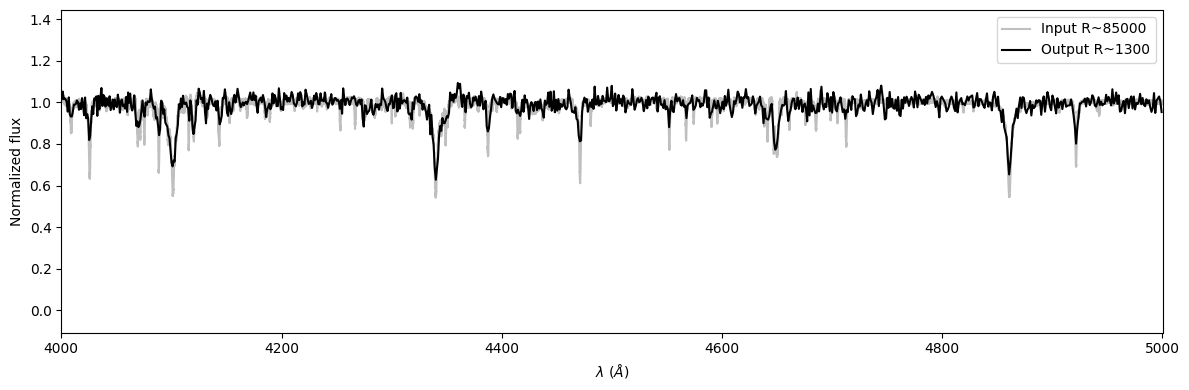

In [8]:
wave_in, flux_in, cdelt_auto = READERS[CONFIG['reader']](CONFIG['spectrum_path'])
cdelt = CONFIG['cdelt'] if CONFIG['cdelt'] is not None else cdelt_auto
print(f'Entrada: {len(wave_in)} pix | cdelt = {cdelt:.4f} Å/pix | R_in = {CONFIG["R_in"]}')

new_wave = build_output_grid(CONFIG['grid_type'], CONFIG['grid_params'])
print(f'Grilla salida: {len(new_wave)} pix | λ ∈ [{new_wave.min():.1f}, {new_wave.max():.1f}] Å')

df_out, rms_out, sigma_pix = degrade_spectrum(
    wave_in, flux_in, cdelt,
    R_in=CONFIG['R_in'], R_out=CONFIG['R_out'],
    lambda_ref=CONFIG['lambda_ref'],
    new_wave_AA=new_wave,
    norm_range=tuple(CONFIG['norm_range']),
    sigma_mode=CONFIG['sigma_mode'],
    target_rms=CONFIG['target_rms'],
    poly_deg=CONFIG['norm_poly_deg'],
)
print(f'σ kernel (pix entrada) = {sigma_pix:.2f} | RMS continuo final = {rms_out:.4f}')

if CONFIG['save_csv']:
    name = Path(CONFIG['spectrum_path']).stem
    out_path = OUT / f'{name}_R{CONFIG["R_out"]}.csv'
    df_out.to_csv(out_path, index=False)
    print(f'Guardado: {out_path}')

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(wave_in, flux_in / np.median(flux_in), c='grey', alpha=0.5, label=f'Input R~{CONFIG["R_in"]}')
ax.plot(df_out['lambda'], df_out['flux'], c='black', label=f'Output R~{CONFIG["R_out"]}')
ax.set_xlim(CONFIG['norm_range'])
ax.set_xlabel(r'$\lambda$ ($\AA$)')
ax.set_ylabel('Normalized flux')
ax.legend()
plt.tight_layout()
plt.savefig(OUT / 'degrade_comparison.pdf', bbox_inches='tight')
plt.show()

## 8. Batch — procesar muchos espectros

Plantilla para procesar una tabla con varios espectros en paralelo (estilo el pipeline original con `pandarallel`).

```python
from pandarallel import pandarallel
pandarallel.initialize(progress_bar=True)

def process(row, target_rms=None):
    wave, flux, cdelt = READERS[row['reader']](row['path'])
    df, rms, _ = degrade_spectrum(
        wave, flux, cdelt,
        R_in=row['R'], R_out=CONFIG['R_out'],
        lambda_ref=CONFIG['lambda_ref'],
        new_wave_AA=build_output_grid(CONFIG['grid_type'], CONFIG['grid_params']),
        norm_range=tuple(CONFIG['norm_range']),
        sigma_mode=CONFIG['sigma_mode'],
        target_rms=target_rms,
    )
    return rms

df_tab['rms'] = df_tab.parallel_apply(process, axis=1)
```